In [1]:
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


from src.data_loader import load_data
from src.preprocess import clean_text
from src.LM.lm_roberta_xml import (
    tokenizer,
    model,
    create_dataloaders,
    train_model,
    evaluate_model,
    get_class_weights
)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [2]:

df = load_data("/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv")
df['Text'] = df['Text'].apply(clean_text)  

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

# ulozenie katagorii
target_names = le.classes_.tolist()


print("Target names:", target_names)
print("Label distribution:")
print(df["Category_encoded"].value_counts())



Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...
Target names: [0, 1]
Label distribution:
Category_encoded
0    505
1    189
Name: count, dtype: int64


In [3]:
# rozdelenie datasetu
X_train_text, X_test_text, y_train_encoded, y_test_encoded = train_test_split(
    df['Text'].tolist(), 
    df['Category_encoded'].tolist(),
    test_size=0.2, 
    random_state=42,
    stratify=df['Category_encoded']
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

Train size: 555
Test size: 139


In [4]:
# konverzia textu a labelov na PyTorch Dataloaders objekty
# batchovanie, rozdelenie na test / train
train_loader, test_loader = create_dataloaders(
    X_train_text, 
    y_train_encoded, 
    X_test_text, 
    y_test_encoded
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# trenovanie LM
class_weights = get_class_weights(y_train_encoded, device)
print("Class weights:", class_weights)

Class weights: tensor([0.6869, 1.8377], device='cuda:0')


Epoch 1/4, Loss: 0.1005
Epoch 2/4, Loss: 0.0806
Epoch 3/4, Loss: 0.0397
Epoch 4/4, Loss: 0.0358
Best threshold (F1-optimal): 0.795
Best F1 score: 0.719

Recall-optimal threshold: 0.198
F1: 0.667 | Precision: 0.500 | Recall: 1.000
              precision    recall  f1-score   support

           0       1.00      0.62      0.77       101
           1       0.50      1.00      0.67        38

    accuracy                           0.73       139
   macro avg       0.75      0.81      0.72       139
weighted avg       0.86      0.73      0.74       139



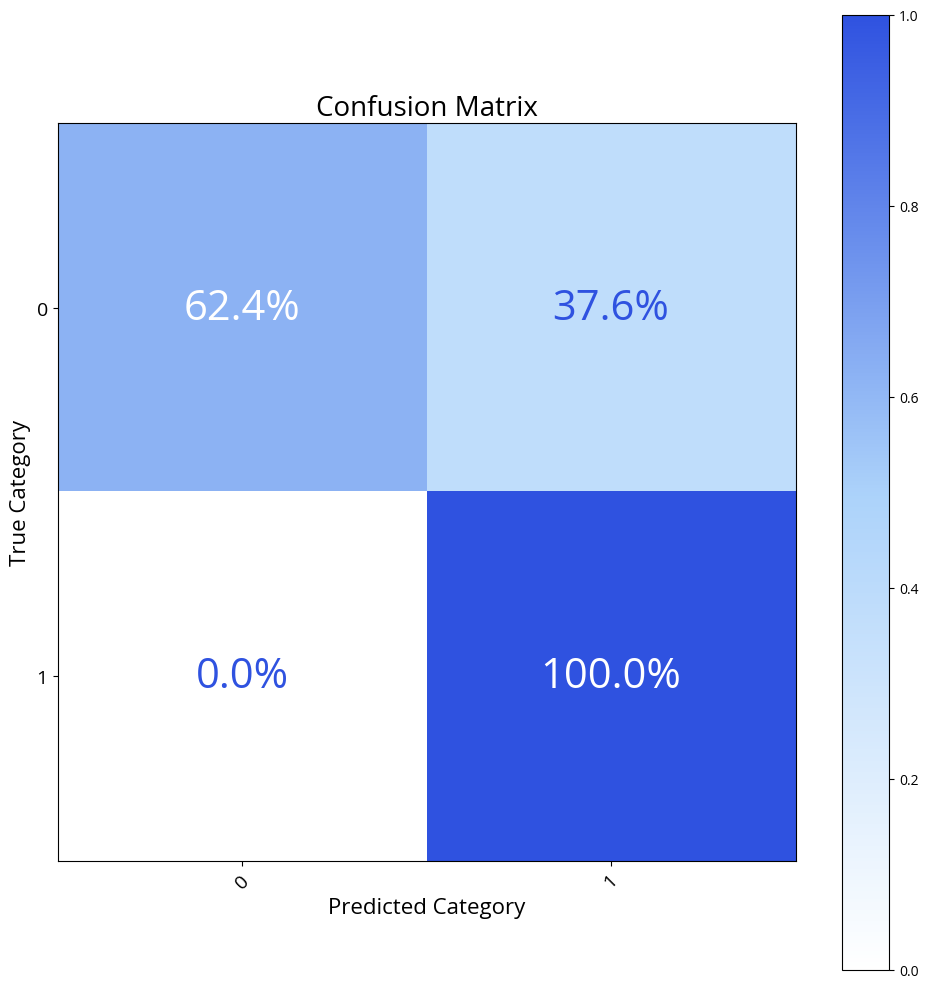

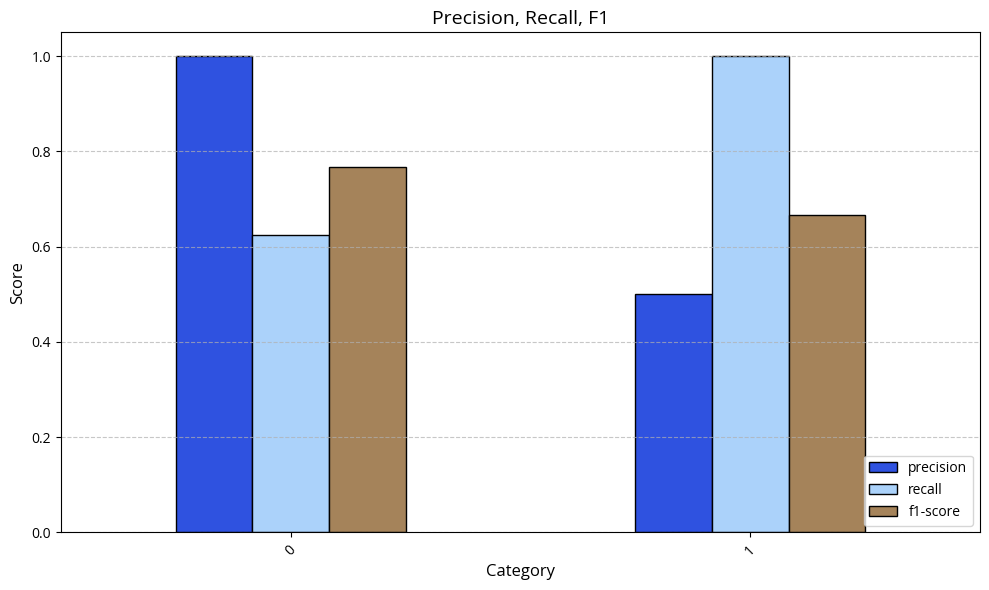

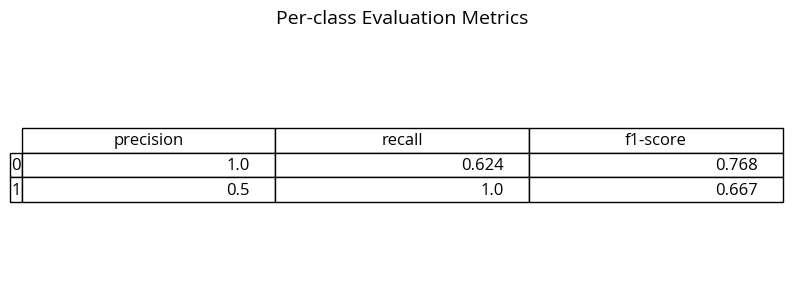

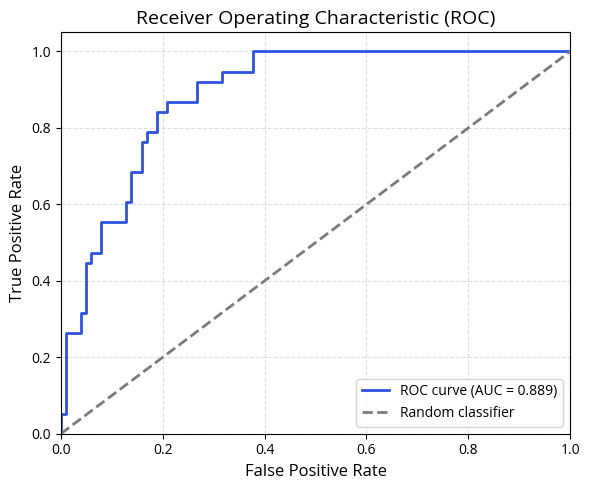

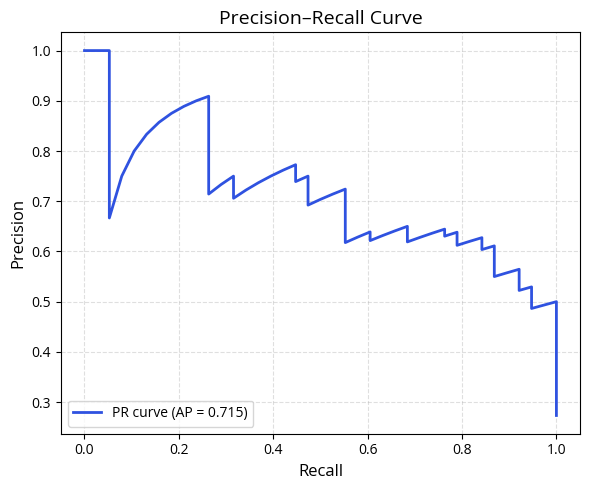

In [6]:
trained_model = train_model(
    model, 
    train_loader, 
    epochs=4, 
    lr=1e-5, 
    use_focal_loss=True, 
    class_weights=class_weights
    )

trained_model.save_pretrained("models/xlm_roberta_binary")
tokenizer.save_pretrained("models/xlm_roberta_binary")


# evaluacia modelu
evaluate_model(
    trained_model, 
    test_loader, 
    label_names=target_names
    )
